In [ ]:
import spacy
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter

/Users/daniel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Cargar modelo en español de spaCy
nlp = spacy.load("es_core_news_sm")

# Función para eliminar los símbolos, emoticones y links
def clean_text(text):
    text = re.sub(r'http\S+|www.\S+', '', text)
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  
        u"\U0001F300-\U0001F5FF"  
        u"\U0001F680-\U0001F6FF"  
        u"\U0001F700-\U0001F77F"  
        u"\U0001F780-\U0001F7FF"  
        u"\U0001F800-\U0001F8FF"  
        u"\U0001F900-\U0001F9FF"  
        u"\U0001FA00-\U0001FA6F"  
        u"\U0001FA70-\U0001FAFF"  
        u"\U00002700-\U000027BF"  
        u"\U0001F1E0-\U0001F1FF"  
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Cargar la base de datos
tweets_file = "tweets_fusionados_limpios.csv"
df_tweets = pd.read_csv(tweets_file)

# Eliminar tweets que no tienen texto
df_tweets_clean = df_tweets.dropna(subset=['Texto'])

# Aplicar la función de limpieza a la columna de texto 
df_tweets_clean['Texto'] = df_tweets_clean['Texto'].apply(clean_text)

# Guardar el resultado filtrado
df_tweets_clean.to_csv('demo_tweets_limpios.csv', index=False)


/var/folders/bs/dp3478zn0bd_r77fww4bz5w40000gn/T/ipykernel_19642/3215124564.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tweets_clean['Texto'] = df_tweets_clean['Texto'].apply(clean_text)


/Users/daniel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/daniel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


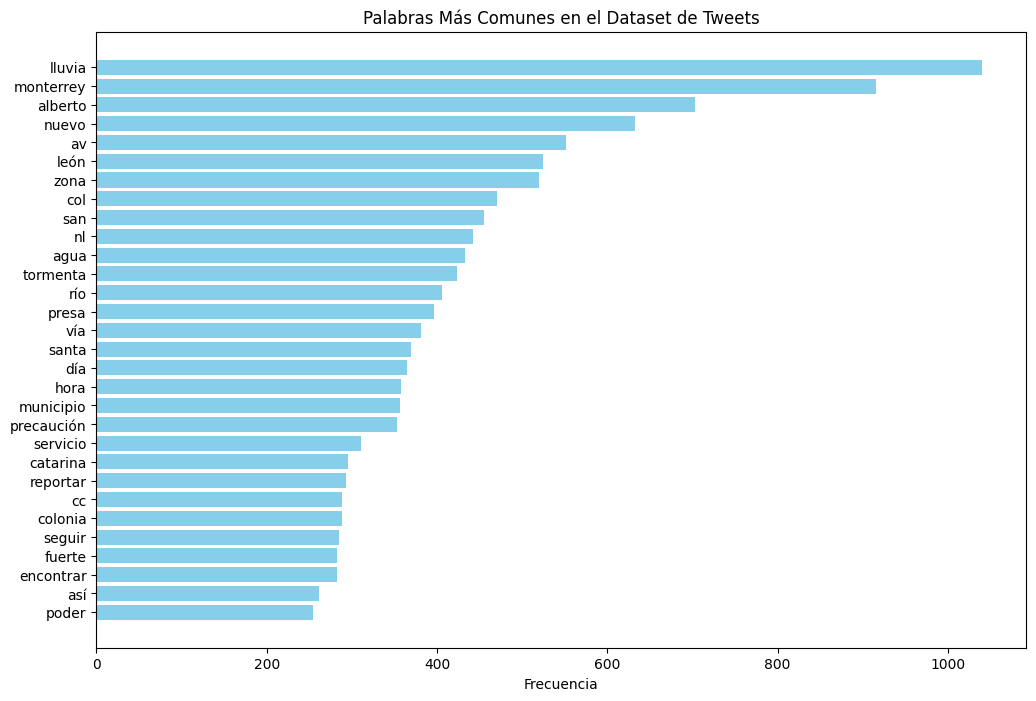

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import spacy
import matplotlib.pyplot as plt

# Descargar stopwords en español
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Cargar el modelo de spaCy para español
nlp = spacy.load('es_core_news_sm')
nlp.max_length = 1500000  # Ajusta este valor según la longitud de tu texto

# Cargar el dataset
df = pd.read_csv('demo_tweets_limpios.csv')

# Función para preprocesar el texto
def preprocess_text(text):
    text = text.lower()  # Convertir a minúsculas
    text = re.sub(r'[^\w\s]', '', text)  # Eliminar puntuación
    return text

# Función para lematizar y eliminar stopwords
def lemmatize_and_remove_stopwords(text):
    doc = nlp(text)
    lemmatized_words = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_punct]
    return lemmatized_words

# Concatenar todos los textos en una sola cadena
all_texts = ' '.join(df['Texto'].astype(str))

# Preprocesar el texto
processed_text = preprocess_text(all_texts)

# Lematizar y eliminar stopwords
lemmatized_words = lemmatize_and_remove_stopwords(processed_text)

# Contar las raíces de las palabras
word_counts = Counter(lemmatized_words)

# Mostrar las palabras más comunes
most_common_words = word_counts.most_common(30)  # Muestra las 50 palabras más comunes

# Preparar datos para la gráfica
words, counts = zip(*most_common_words)

# Crear la gráfica
plt.figure(figsize=(12, 8))
plt.barh(words, counts, color='skyblue')
plt.xlabel('Frecuencia')
plt.title('Palabras Más Comunes en el Dataset de Tweets')
plt.gca().invert_yaxis()  # Para que la palabra más frecuente esté en la parte superior
plt.show()